In [1]:
import numpy as np
import pandas as pd
import random

In [2]:
FOLD = 0

In [3]:
df = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold{FOLD}_selected_genomic_windows_centered.tsv", sep="\t")

In [4]:
df

,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,centered_flat_end
0,chr6,65816576,67127296,fold0,0.661027,56.0,182.0,65536000,66846720,193,319
1,chr5,45508608,46819328,fold0,0.676980,138.0,307.0,45438976,46749696,172,340
2,chr3,152107008,153417728,fold0,0.693888,354.0,455.0,152410112,153720832,206,306
3,chr5,95827968,97138688,fold0,0.662273,260.0,368.0,95946752,97257472,202,310
4,chr11,65921024,67231744,fold0,0.746112,76.0,199.0,65677312,66988032,195,317
5,chr3,127623168,128933888,fold0,0.700263,322.0,455.0,127893504,129204224,190,322
6,chr3,51795968,53106688,fold0,0.855747,247.0,416.0,51949568,53260288,172,340
7,chr4,127782912,129093632,fold0,0.873459,124.0,286.0,127678464,128989184,175,337
8,chr5,48785408,50096128,fold0,0.679395,254.0,358.0,48887808,50198528,204,308
9,chr3,105455616,106766336,fold0,0.776279,276.0,390.0,105613312,106924032,199,313


In [5]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return one_hot_encoded

In [6]:
from torch.utils.data import Dataset, DataLoader
import torch

In [7]:
class GenomicSequenceDataset(Dataset):
    def __init__(self, coord_df, genome_fasta):
        self.coords = coord_df
        self.genome = genome_fasta

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        TARGET_LEN = 1310720
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        seq = self.genome[chrom][start:end].seq.upper()
        if len(seq) != TARGET_LEN:
            seq = seq[:TARGET_LEN].ljust(TARGET_LEN, 'N')

        one_hot = one_hot_encode_sequence(seq)
        return torch.from_numpy(one_hot.copy())

In [8]:
from pyfaidx import Fasta

In [9]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [10]:
orig_dataset = GenomicSequenceDataset(df, genome)

orig_loader = DataLoader(orig_dataset, batch_size=16, shuffle=False)

In [11]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model_v2_compatible import SeqNN

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [13]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_904526/ipykernel_2491999/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_f

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [14]:
preds_all = []

model.eval()
with torch.no_grad():
    for batch in orig_loader:
        batch = batch.to(device)  # shape [B, 4, L]
        
        # Predict
        preds = model(batch).cpu()  # shape [B, T]
        preds_all.extend(preds)

In [15]:
preds_all = torch.cat(preds_all, dim=0)

In [16]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [18]:
df

,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,centered_flat_end
0,chr6,65816576,67127296,fold0,0.661027,56.0,182.0,65536000,66846720,193,319
1,chr5,45508608,46819328,fold0,0.676980,138.0,307.0,45438976,46749696,172,340
2,chr3,152107008,153417728,fold0,0.693888,354.0,455.0,152410112,153720832,206,306
3,chr5,95827968,97138688,fold0,0.662273,260.0,368.0,95946752,97257472,202,310
4,chr11,65921024,67231744,fold0,0.746112,76.0,199.0,65677312,66988032,195,317
5,chr3,127623168,128933888,fold0,0.700263,322.0,455.0,127893504,129204224,190,322
6,chr3,51795968,53106688,fold0,0.855747,247.0,416.0,51949568,53260288,172,340
7,chr4,127782912,129093632,fold0,0.873459,124.0,286.0,127678464,128989184,175,337
8,chr5,48785408,50096128,fold0,0.679395,254.0,358.0,48887808,50198528,204,308
9,chr3,105455616,106766336,fold0,0.776279,276.0,390.0,105613312,106924032,199,313


0


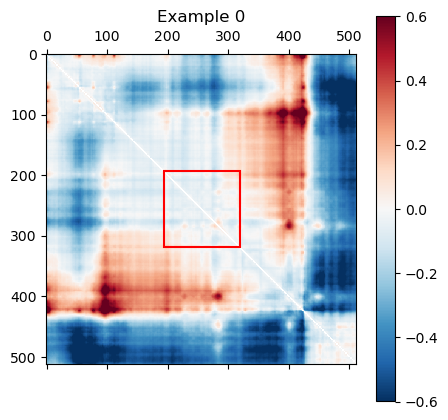

1


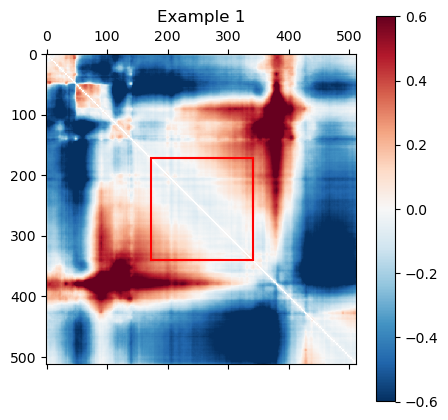

2


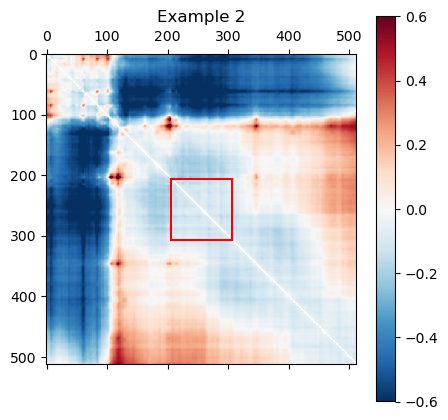

3


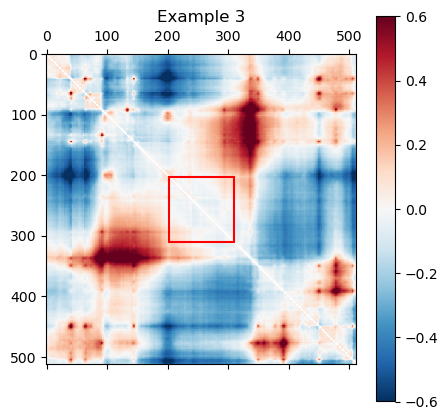

4


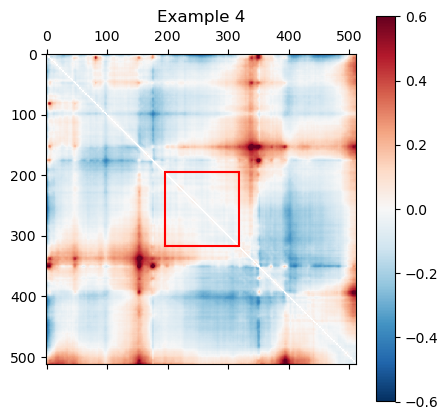

5


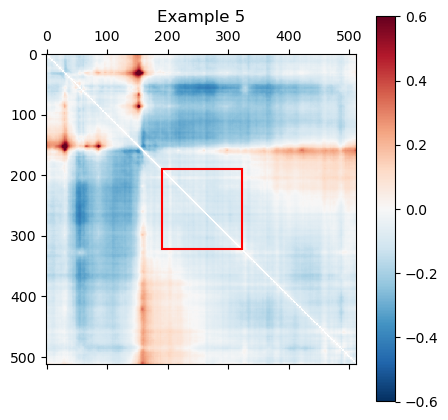

6


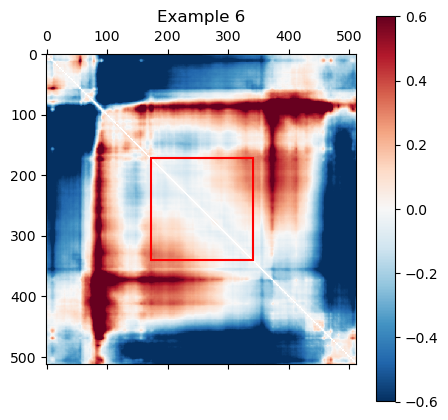

7


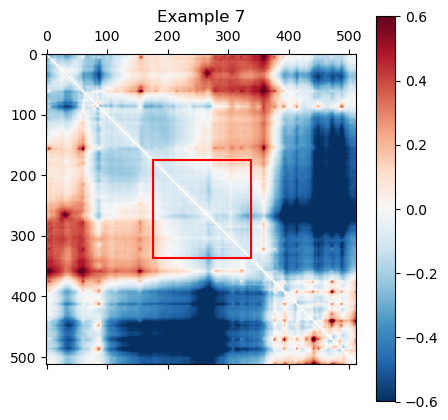

8


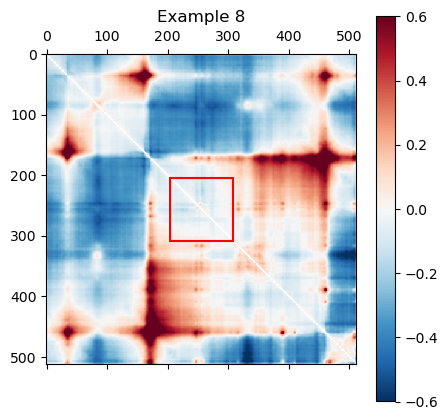

9


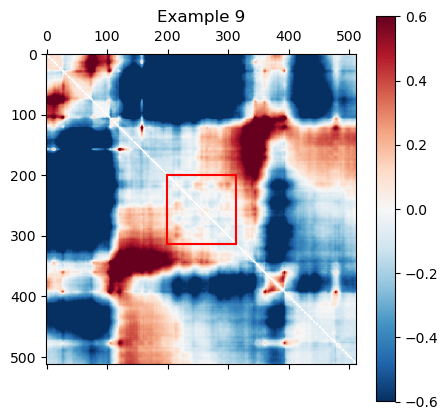

In [19]:
for i in range(10):
    print(i)
    matrix = from_upper_triu(preds_all[i,:], matrix_len=512, num_diags=2)
    
    flat_start = df.loc[i, "centered_flat_start"]
    flat_end = df.loc[i, "centered_flat_end"]
    
    plt.figure(figsize=(5, 5))
    ax = plt.gca()  # Get the current axes
    
    im = ax.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar(im)

    # Add red square along diagonal if flat_start/end are valid
    if not np.isnan(flat_start) and not np.isnan(flat_end):
        width = flat_end - flat_start
        rect = patches.Rectangle(
            (flat_start, flat_start),  # (x, y) = bottom-left corner
            width,                     # width and height are same for diagonal square
            width,
            linewidth=1.5,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    plt.title(f"Example {i}")
    plt.show()